In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [13]:
from google.colab import drive
drive.mount('/content/drive')
attention_dir = Path("/content/drive/MyDrive/attention-sink/data/attentions")

files = sorted(attention_dir.glob("*.pt"))

print(f"Found {len(files)} attention files.")
print(attention_dir.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 100 attention files.
True


In [14]:
def load_attention(filename):
    return torch.load(attention_dir / filename)

In [15]:
sample = load_attention("english_question_01.pt")

print(sample.keys())

dict_keys(['language', 'category', 'prompt', 'tokens', 'token_positions', 'seq_len', 'input_ids', 'attentions'])


In [16]:
print("Language:", sample["language"])
print("Category:", sample["category"])
print("Prompt:", sample["prompt"])
print("Sequence length:", sample["seq_len"])

Language: english
Category: question
Prompt: What causes rain?
Sequence length: 4


In [17]:
sample = torch.load(attention_dir / "english_question_01.pt")

print(sample.keys())

print(type(sample["attentions"]))
print(sample["attentions"])

dict_keys(['language', 'category', 'prompt', 'tokens', 'token_positions', 'seq_len', 'input_ids', 'attentions'])
<class 'list'>
[tensor([[[[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
          [6.7188e-01, 3.2812e-01, 0.0000e+00, 0.0000e+00],
          [3.5547e-01, 5.8594e-01, 5.8105e-02, 0.0000e+00],
          [7.8516e-01, 3.9978e-03, 6.0654e-04, 2.1094e-01]],

         [[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
          [2.1606e-02, 9.7656e-01, 0.0000e+00, 0.0000e+00],
          [1.1969e-04, 7.5531e-04, 1.0000e+00, 0.0000e+00],
          [9.3359e-01, 1.6602e-02, 3.6621e-04, 4.9561e-02]],

         [[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
          [8.1641e-01, 1.8262e-01, 0.0000e+00, 0.0000e+00],
          [6.7383e-02, 8.2031e-01, 1.1133e-01, 0.0000e+00],
          [1.0071e-03, 6.6406e-02, 2.6172e-01, 6.7188e-01]],

         [[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
          [1.0986e-02, 9.8828e-01, 0.0000e+00, 0.0000e+00],
          [9.4891e-05, 1.

In [18]:
attentions = sample["attentions"]

print("Number of layers:", len(attentions))

for i, layer in enumerate(attentions):
    print(f"Layer {i}: {layer.shape}")

Number of layers: 28
Layer 0: torch.Size([1, 16, 4, 4])
Layer 1: torch.Size([1, 16, 4, 4])
Layer 2: torch.Size([1, 16, 4, 4])
Layer 3: torch.Size([1, 16, 4, 4])
Layer 4: torch.Size([1, 16, 4, 4])
Layer 5: torch.Size([1, 16, 4, 4])
Layer 6: torch.Size([1, 16, 4, 4])
Layer 7: torch.Size([1, 16, 4, 4])
Layer 8: torch.Size([1, 16, 4, 4])
Layer 9: torch.Size([1, 16, 4, 4])
Layer 10: torch.Size([1, 16, 4, 4])
Layer 11: torch.Size([1, 16, 4, 4])
Layer 12: torch.Size([1, 16, 4, 4])
Layer 13: torch.Size([1, 16, 4, 4])
Layer 14: torch.Size([1, 16, 4, 4])
Layer 15: torch.Size([1, 16, 4, 4])
Layer 16: torch.Size([1, 16, 4, 4])
Layer 17: torch.Size([1, 16, 4, 4])
Layer 18: torch.Size([1, 16, 4, 4])
Layer 19: torch.Size([1, 16, 4, 4])
Layer 20: torch.Size([1, 16, 4, 4])
Layer 21: torch.Size([1, 16, 4, 4])
Layer 22: torch.Size([1, 16, 4, 4])
Layer 23: torch.Size([1, 16, 4, 4])
Layer 24: torch.Size([1, 16, 4, 4])
Layer 25: torch.Size([1, 16, 4, 4])
Layer 26: torch.Size([1, 16, 4, 4])
Layer 27: torch.S

In [41]:
figures_dir = Path("/content/drive/MyDrive/attention-sink/results/figures")

figures_dir.mkdir(
    parents=True,
    exist_ok=True
)

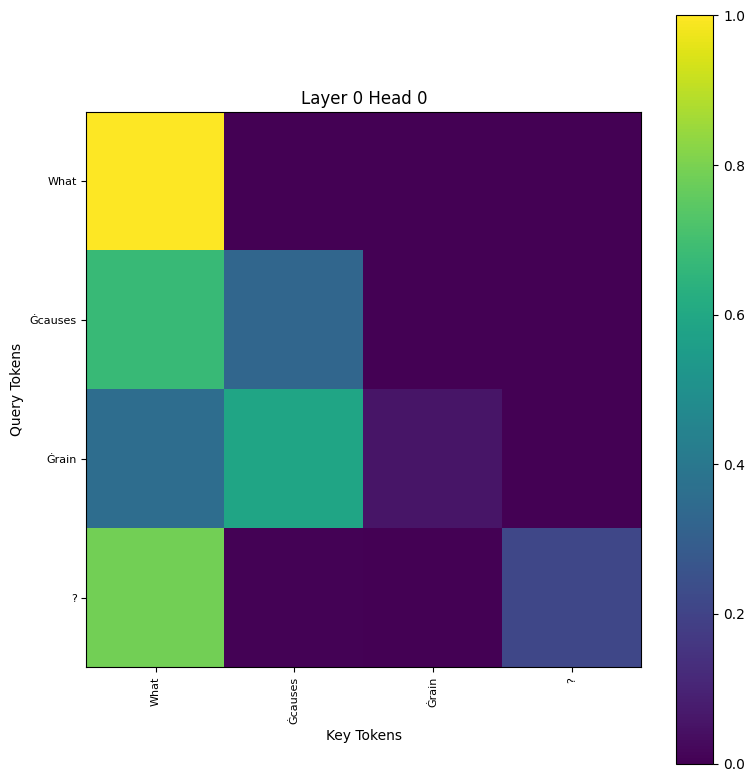

<Figure size 640x480 with 0 Axes>

In [42]:
layer = 0
head = 0

matrix = attentions[layer][0, head].float().numpy()

tokens = sample["tokens"]

plt.figure(figsize=(8, 8))

plt.imshow(matrix, cmap="viridis")

plt.colorbar()

plt.xticks(range(len(tokens)), tokens, rotation=90, fontsize=8)
plt.yticks(range(len(tokens)), tokens, fontsize=8)

plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")

plt.title(f"Layer {layer} Head {head}")

plt.tight_layout()

plt.show()

plt.savefig(
    figures_dir / "layer0_head0_attention.png",
    dpi=300,
    bbox_inches="tight"
)

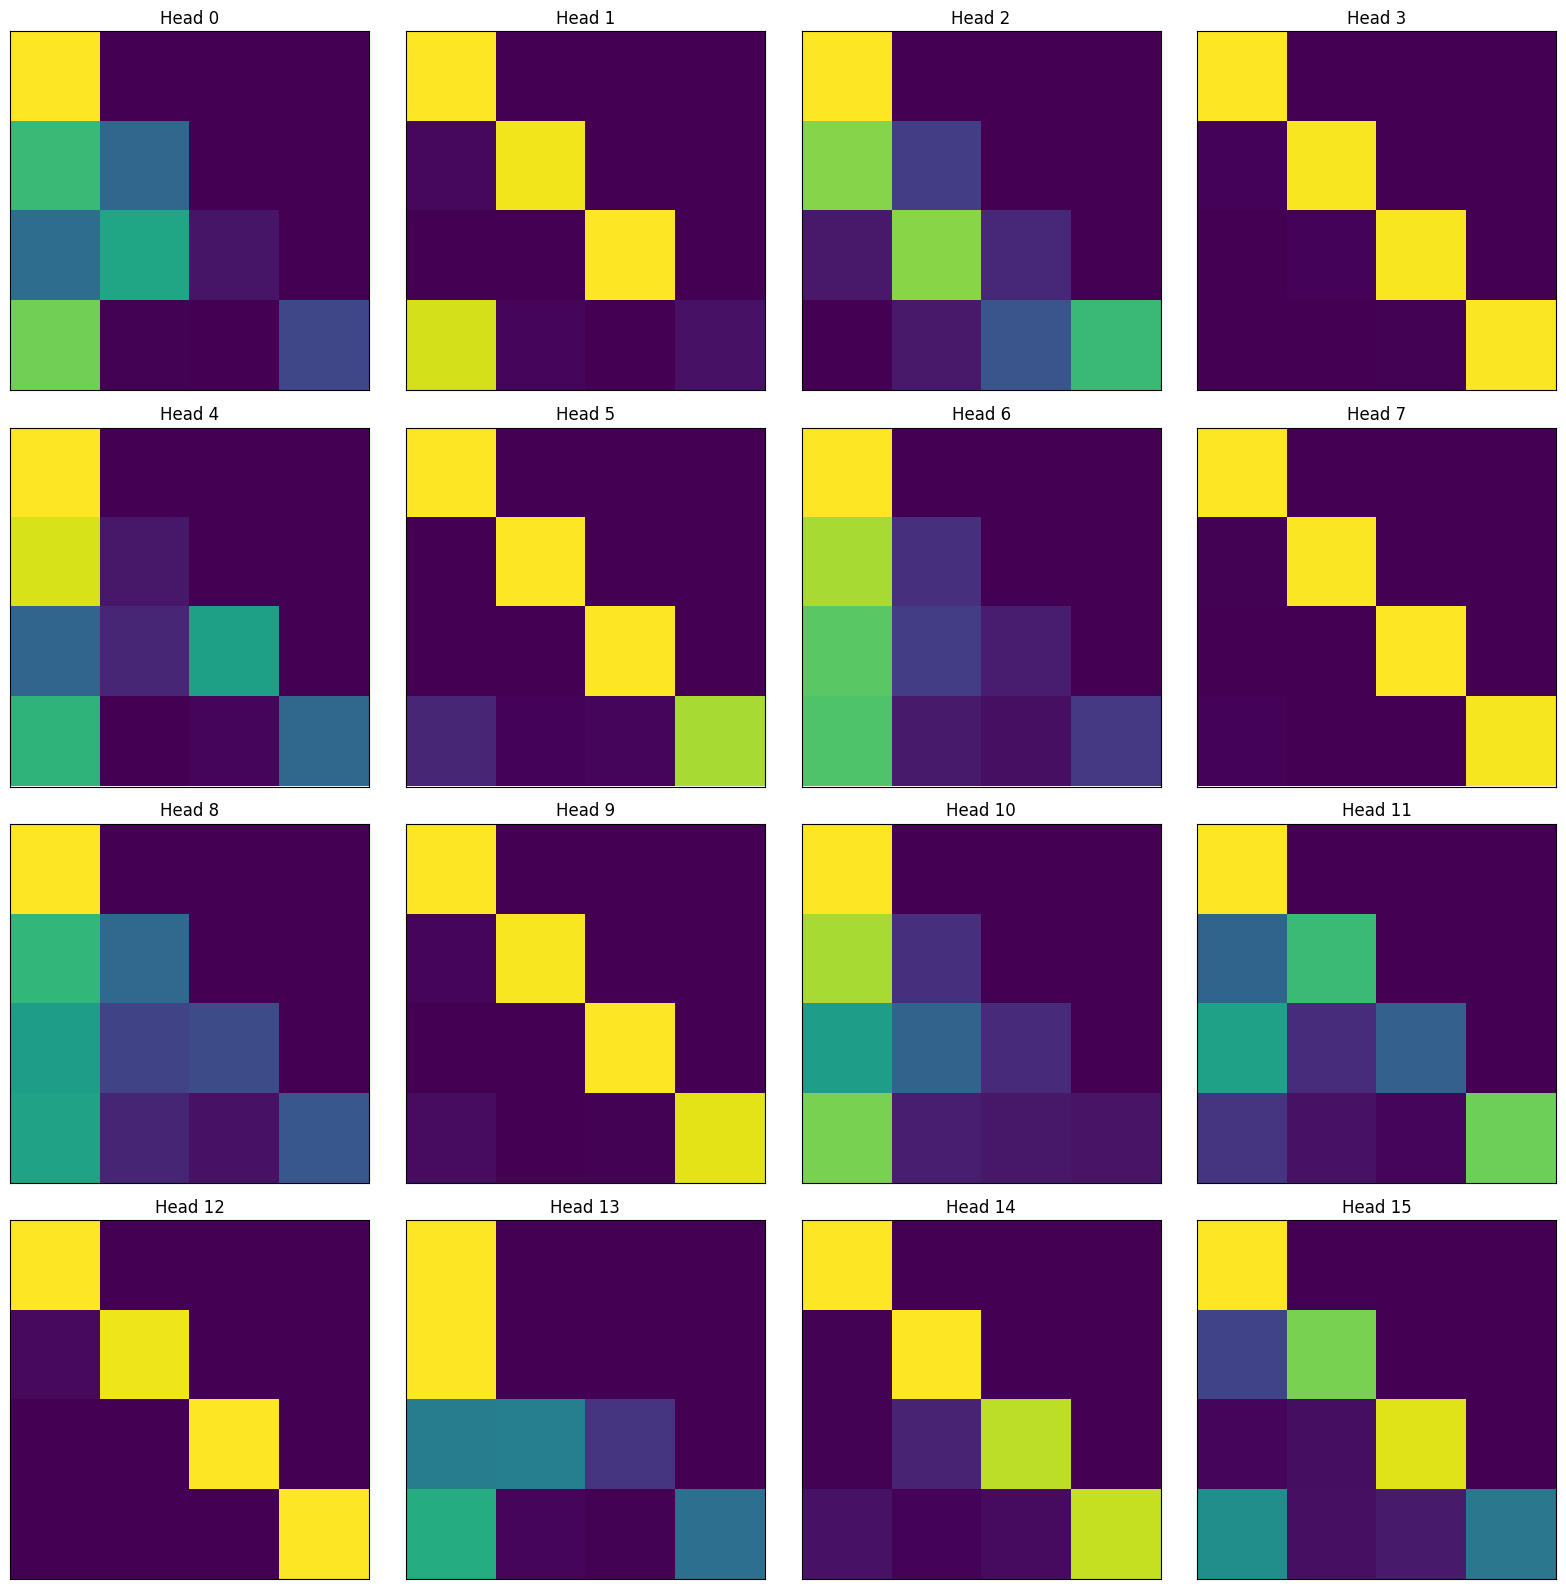

<Figure size 640x480 with 0 Axes>

In [43]:
layer = 0

heads = attentions[layer][0]

num_heads = heads.shape[0]

cols = 4
rows = int(np.ceil(num_heads / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))

axes = axes.flatten()

for head in range(num_heads):

    axes[head].imshow(heads[head].float().numpy(), cmap="viridis")

    axes[head].set_title(f"Head {head}")

    axes[head].set_xticks([])
    axes[head].set_yticks([])

for ax in axes[num_heads:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

plt.savefig(
    figures_dir / "layer0_all_head_attention.png",
    dpi=300,
    bbox_inches="tight"
)

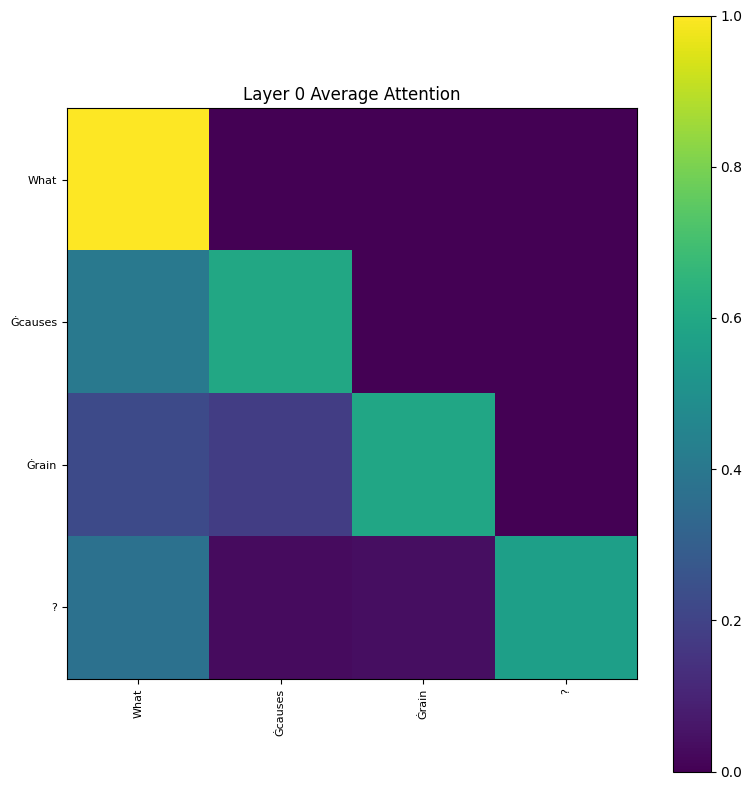

<Figure size 640x480 with 0 Axes>

In [44]:
layer = 0

average = attentions[layer][0].mean(dim=0).float().numpy()

plt.figure(figsize=(8,8))

plt.imshow(average, cmap="viridis")

plt.colorbar()

plt.xticks(range(len(tokens)), tokens, rotation=90, fontsize=8)
plt.yticks(range(len(tokens)), tokens, fontsize=8)

plt.title(f"Layer {layer} Average Attention")

plt.tight_layout()

plt.show()

plt.savefig(
    figures_dir / "layer0_avg_attention.png",
    dpi=300,
    bbox_inches="tight"
)

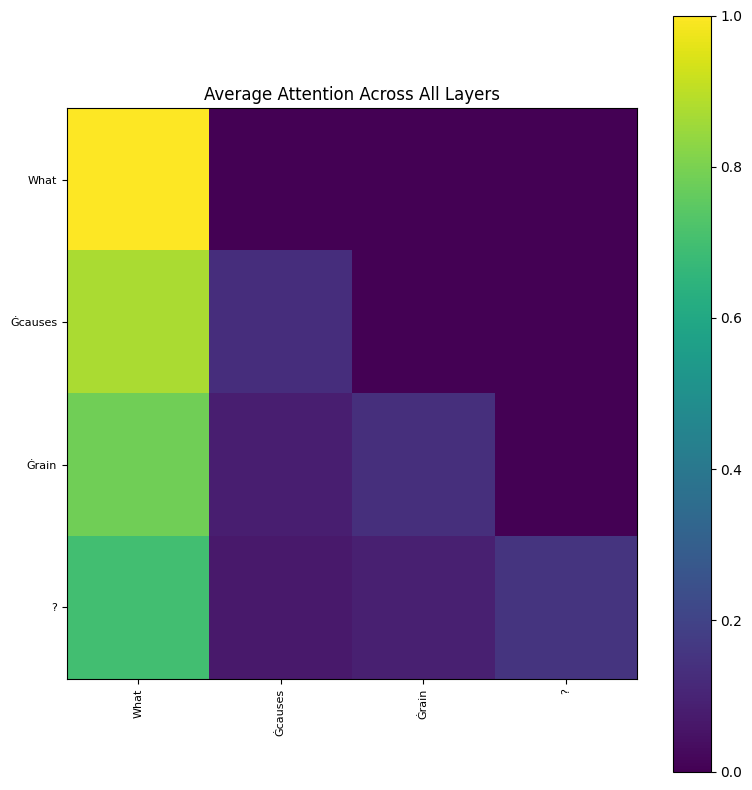

<Figure size 640x480 with 0 Axes>

In [45]:
layer_maps = []

for layer in attentions:

    avg = layer[0].mean(dim=0)

    layer_maps.append(avg)

overall = torch.stack(layer_maps).mean(dim=0).float().numpy()

plt.figure(figsize=(8,8))

plt.imshow(overall, cmap="viridis")

plt.colorbar()

plt.xticks(range(len(tokens)), tokens, rotation=90, fontsize=8)
plt.yticks(range(len(tokens)), tokens, fontsize=8)

plt.title("Average Attention Across All Layers")

plt.tight_layout()

plt.show()

plt.savefig(
    figures_dir / "all_layer_avg_attention.png",
    dpi=300,
    bbox_inches="tight"
)

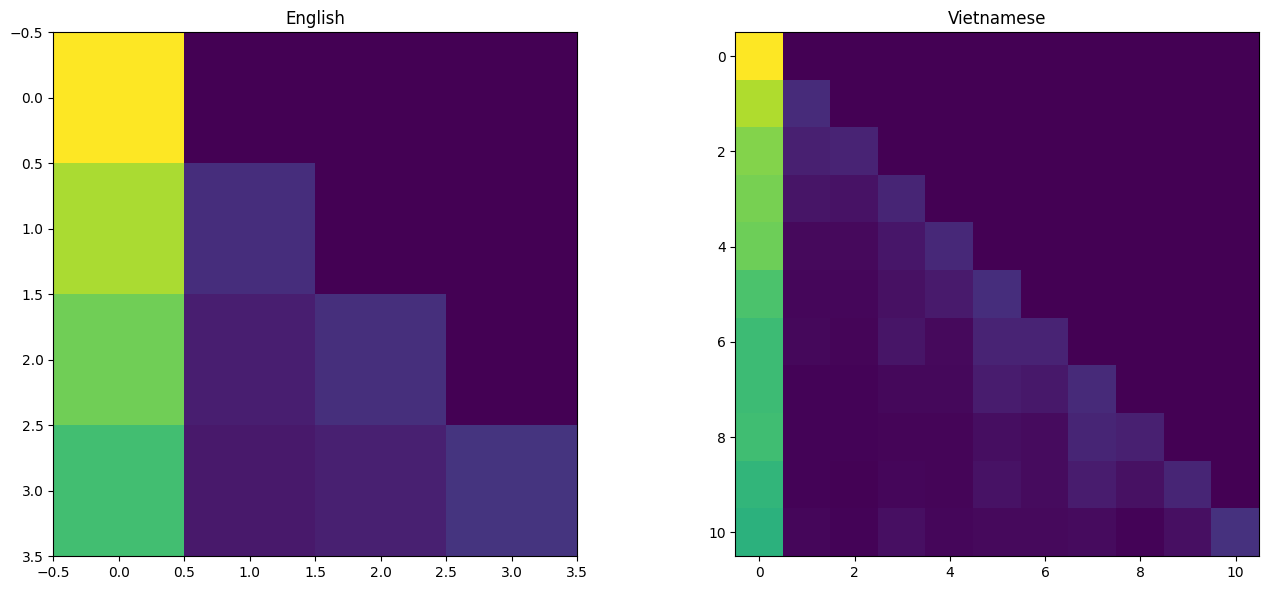

<Figure size 640x480 with 0 Axes>

In [46]:
english = load_attention("english_question_01.pt")
vietnamese = load_attention("vietnamese_question_01.pt")

def average_attention(data):

    attentions = data["attentions"]

    layer_maps = []

    for layer in attentions:
        layer_maps.append(layer[0].mean(dim=0))

    return torch.stack(layer_maps).mean(dim=0).float().numpy()


eng = average_attention(english)
vie = average_attention(vietnamese)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(eng, cmap="viridis")
axes[0].set_title("English")

axes[1].imshow(vie, cmap="viridis")
axes[1].set_title("Vietnamese")

plt.tight_layout()
plt.show()

plt.savefig(
    figures_dir / "eng_vie_avg_attention.png",
    dpi=300,
    bbox_inches="tight"
)


In [28]:
def average_attention(data):
    layer_maps = []

    for layer in data["attentions"]:
        avg_head = layer[0].mean(dim=0)
        layer_maps.append(avg_head)

    overall = torch.stack(layer_maps).mean(dim=0)

    return overall.float().numpy()

def sink_score(data):
    overall = average_attention(data)

    return float(overall[:, 0].mean())

In [29]:
results = []

for file in sorted(attention_dir.glob("*.pt")):

    data = torch.load(file)
    score = sink_score(data)

    results.append({
        "file": file.stem,
        "language": data["language"],
        "category": data["category"],
        "seq_len": data["seq_len"],
        "sink_score": score
    })

print(f"Processed {len(results)} prompts.")

Processed 100 prompts.


In [30]:
import pandas as pd

df = pd.DataFrame(results)

df.head()

,file,language,category,seq_len,sink_score
0,english_code_01,english,code,12,0.727539
1,english_code_02,english,code,11,0.743253
2,english_code_03,english,code,10,0.748828
3,english_code_04,english,code,6,0.779948
4,english_code_05,english,code,10,0.736328


In [31]:
results_dir = Path("/content/drive/MyDrive/attention-sink/results")

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

df.to_csv(
    results_dir / "sink_scores.csv",
    index=False
)

print("Saved!")

Saved!


In [32]:
language_summary = (

    df.groupby("language")["sink_score"]

      .mean()

      .sort_values(ascending=False)

)

print(language_summary)

language
english       0.748557
vietnamese    0.729932
Name: sink_score, dtype: float64


In [33]:
category_summary = (

    df.groupby("category")["sink_score"]

      .mean()

      .sort_values(ascending=False)

)

print(category_summary)

category
question     0.768948
list         0.748959
code         0.741365
gibberish    0.737760
story        0.699191
Name: sink_score, dtype: float64


In [34]:
df.sort_values(
    "sink_score",
    ascending=False
).head(10)

,file,language,category,seq_len,sink_score
30,english_question_01,english,question,4,0.836914
36,english_question_07,english,question,5,0.825000
34,english_question_05,english,question,5,0.821875
31,english_question_02,english,question,6,0.805339
32,english_question_03,english,question,6,0.804036
33,english_question_04,english,question,7,0.794085
35,english_question_06,english,question,7,0.780692
3,english_code_04,english,code,6,0.779948
26,english_list_07,english,list,6,0.776693
27,english_list_08,english,list,6,0.776693


In [35]:
df.sort_values(
    "sink_score",
    ascending=True
).head(10)

,file,language,category,seq_len,sink_score
40,english_story_01,english,story,21,0.671317
90,vietnamese_story_01,vietnamese,story,22,0.685369
96,vietnamese_story_07,vietnamese,story,18,0.687500
93,vietnamese_story_04,vietnamese,story,20,0.691602
58,vietnamese_code_09,vietnamese,code,15,0.692448
46,english_story_07,english,story,14,0.693359
48,english_story_09,english,story,14,0.694475
99,vietnamese_story_10,vietnamese,story,16,0.694580
41,english_story_02,english,story,14,0.694754
45,english_story_06,english,story,14,0.695033


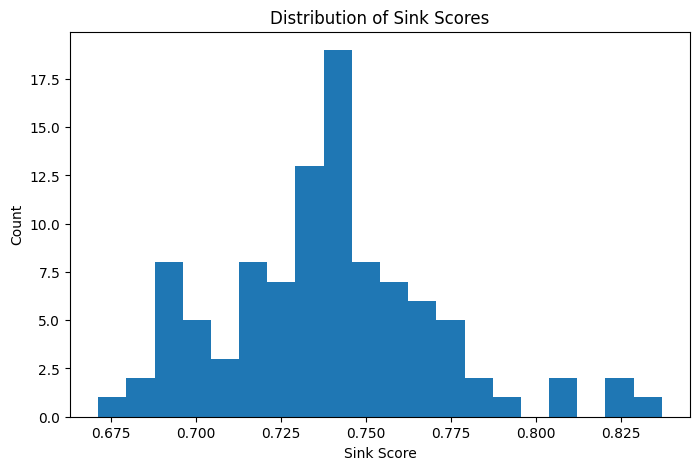

<Figure size 640x480 with 0 Axes>

In [47]:
plt.figure(figsize=(8,5))
plt.hist(df["sink_score"], bins=20)
plt.xlabel("Sink Score")
plt.ylabel("Count")
plt.title("Distribution of Sink Scores")
plt.show()

plt.savefig(
    figures_dir / "distribution_of_sink_scores.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 600x500 with 0 Axes>

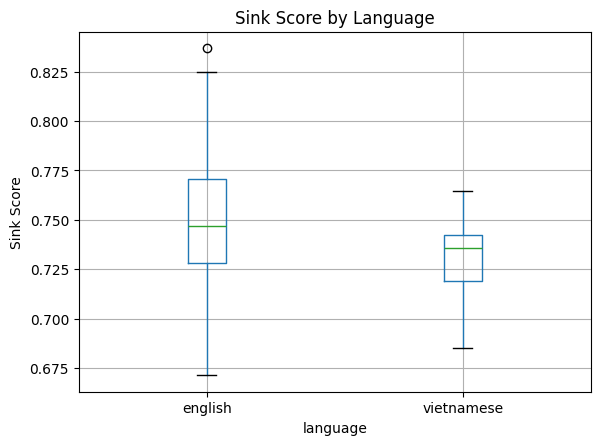

<Figure size 640x480 with 0 Axes>

In [49]:
plt.figure(figsize=(6,5))

df.boxplot(column="sink_score", by="language")

plt.suptitle("")
plt.title("Sink Score by Language")

plt.ylabel("Sink Score")

plt.show()

plt.savefig(
    figures_dir / "eng_vie_sink_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 800x500 with 0 Axes>

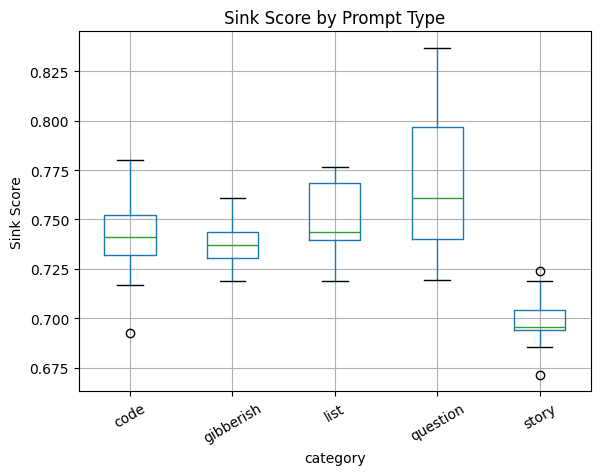

<Figure size 640x480 with 0 Axes>

In [50]:
plt.figure(figsize=(8,5))

df.boxplot(column="sink_score", by="category")

plt.suptitle("")
plt.title("Sink Score by Prompt Type")

plt.ylabel("Sink Score")

plt.xticks(rotation=30)

plt.show()

plt.savefig(
    figures_dir / "sink_score_by_prompt_type.png",
    dpi=300,
    bbox_inches="tight"
)